In [1]:
import random
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import torch
from omegaconf import OmegaConf
from rdkit import Chem
from rdkit.Chem import  DataStructs, rdMolDescriptors, Descriptors
import torch_geometric.data as gd
from gflownet.proxy.mol_utils import smiles2graph
from gflownet.utils.conditioning import TemperatureConditional
from gflownet.models.graph_transformer import GraphTransformerGFN
from gflownet.algo.trajectory_balance import TrajectoryBalance
from gflownet.algo.flow_matching import FlowMatching
from gflownet.envs.graph_building_env import GraphBuildingEnv
from gflownet.envs.frag_mol_env import FragMolBuildingEnvContext
from gflownet.models import bengio2021flow
from utils import load_proxy_sol
import warnings
from scipy.stats import pearsonr, spearmanr
from rdkit import RDLogger   

RDLogger.DisableLog('rdApp.*')
warnings.filterwarnings("ignore", category=DeprecationWarning)

/home/john-savvas/Documents/thesis_code/gflownet/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Utils

In [2]:
def generate_maccs_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius=1, nBits=2048)

def top_k_tanimoto(smiles, k):
    maccs_fingerprints = [generate_maccs_fingerprint(smile) for smile in smiles[:k]]
    n_samples = len(maccs_fingerprints)
    similarity_matrix = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        for j in range(i, n_samples):
            similarity = DataStructs.TanimotoSimilarity(maccs_fingerprints[i], maccs_fingerprints[j])
            similarity_matrix[i, j] = similarity
            similarity_matrix[j, i] = similarity 
    upper_triangular = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]
    average_similarity = np.mean(upper_triangular)
    return average_similarity

# def top_k_diverse(df, k, threshold):
#     df = df.sort_values(by="reward", ascending=False).reset_index(drop=True)
#     best_smiles = [df["smiles"][0]]
#     prev_smiles = best_smiles[0]
#     best_rewards = [df["reward"][0]]
#     for i in range(1, len(df)):
#         current_smile = df["smiles"][i]
#         current_reward = df["reward"][i]
#         is_diverse = DataStructs.TanimotoSimilarity(
#                 generate_maccs_fingerprint(current_smile),
#                 generate_maccs_fingerprint(prev_smiles),
#             ) < threshold
#         if is_diverse:
#             best_smiles.append(current_smile)
#             best_rewards.append(current_reward)
#             prev_smiles = current_smile
#         if len(best_smiles) >= k:
#             break
#     return pd.DataFrame({"smiles": best_smiles, "reward": best_rewards})    

def top_k_diverse(df, k, threshold):
    df = df.sort_values(by="reward", ascending=False).reset_index(drop=True)
    mode_fps = []
    smiles_seen = set()
    div_smiles = []
    rewards = []
    logprobs = []
    for i in range(1, len(df)):
        smile = df["smiles"][i]
        fp = generate_maccs_fingerprint(smile)
        is_new_mode = all(
            DataStructs.TanimotoSimilarity(fp, existing_fp) < threshold for existing_fp in mode_fps
        )
        if is_new_mode and smile not in smiles_seen:
            div_smiles.append(smile)
            rewards.append(df["reward"][i])
            mode_fps.append(fp)
            logprobs.append(df["policy"][i])
        if len(div_smiles) >= k:
            break
    return pd.DataFrame({"smiles": div_smiles, "reward": rewards, "policy": logprobs})  

### Inference the molecules

In [18]:
ids = ["fm_experiment(lr=1e-4)", "db_lr(1e-4)", "tb_lr(1e-4)", "subtb_lr(1e-4)"]
current_dir = Path.cwd().parent
proxy_model = load_proxy_sol()  
df_ids = []
# Iterate over each algo
for i,id in enumerate(ids):
    yaml_dir = current_dir / "src" / "gflownet" / "tasks" / "logs" / id / "config.yaml"
    model_dir = current_dir / "src" / "gflownet" / "tasks" / "logs" / id / "model_state.pt"
    cfg = OmegaConf.load(yaml_dir)
    # Load env
    env = GraphBuildingEnv()
    temp_cond = TemperatureConditional(cfg)
    num_cond_dim = temp_cond.encoding_size()
    ctx = FragMolBuildingEnvContext(
        max_frags=cfg.algo.max_nodes,
        num_cond_dim=num_cond_dim,
        fragments=bengio2021flow.FRAGMENTS,
    )
    # Load GFN Model
    model = GraphTransformerGFN(
        env_ctx=ctx,
        cfg=cfg,
        num_graph_out=cfg.algo.tb.do_predict_n + 1,
        do_bck=cfg.algo.tb.do_parameterize_p_b,
    )
    model.load_state_dict((torch.load(model_dir)["models_state_dict"][0])) 
    model.eval()
    # Load Algo
    if cfg.algo.method == "TB":
        algo = TrajectoryBalance(env, ctx, cfg)
    else:
        algo = FlowMatching(env, ctx, cfg)
    # Load cond_info
    seeds = [40] #, 42, 43] 
    total_smiles = []
    total_preds = []
    total_policy = []
    for seed in seeds:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        num_gen = 100
        seed_preds = []
        seed_smiles = []
        seed_policy = []
        for _ in range(250):
            # Sample from the GFlowNet
            cond_info = temp_cond.sample(num_gen)["encoding"]
            samples = algo.create_training_data_from_own_samples(model=model, n=num_gen, cond_info=cond_info)
            trajectories = [sample["traj"] for sample in samples]
            rdkit_mols = [ctx.graph_to_obj(traj[-1][0]) for traj in trajectories]
            smiles = [Chem.MolToSmiles(mol) for mol in rdkit_mols]
            # Get preds
            graphs = [smiles2graph(Chem.MolFromSmiles(smile)) for smile in smiles]
            batch = gd.Batch.from_data_list([g for g in graphs if g is not None])
            preds = (
                proxy_model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze(dim=-1).cpu().detach().numpy()
            )
            min_sol = -13.71
            max_sol = 2.41
            scaled_preds = list(1 - ((preds - min_sol) / (max_sol - min_sol)))
            policy = [p["fwd_logprob"].item() for p in samples]
            # Add batch preds
            seed_preds.extend(scaled_preds)
            seed_smiles.extend(smiles)
            seed_policy.extend(policy)
        # Add seed preds
        total_smiles.append(seed_smiles)
        total_preds.append(seed_preds)
        total_policy.append(seed_policy)
    # Add each seed smiles and preds to total list
    df_all = [pd.DataFrame({"smiles": sm, "reward": pred, "policy": pol})
            for sm, pred, pol in zip(total_smiles, total_preds, total_policy)]
    # Each list in df_ids contains a list of dataframes for each seed
    df_ids.append(df_all)

KeyboardInterrupt: 

In [5]:
with open("inference_list.pkl", "wb") as file:
    pickle.dump(df_ids, file)

### Top 1000 Diverse

In [5]:
from rdkit import RDLogger   
RDLogger.DisableLog('rdApp.*')

for ix, id in enumerate(ids):
    mean_pearson = []
    mean_sp = []
    mean_highest = []
    cross_entropy = []
    for df in df_ids[ix]:  # each df is one run
        #top_k_df = top_k_diverse(df, k, 0.3)
        pearson, _ = pearsonr(df["reward"], df["policy"])
        spearman, _ = spearmanr(df["reward"], df["policy"])
        mean_pearson.append(pearson)
        mean_sp.append(spearman)
        
        df['prob'] = np.exp(df['policy'])
        
        df['reward_bin'] = pd.qcut(df['reward'], q=10, labels=False)  
    
        df['is_high_bin'] = df['reward_bin'] >= 6
        
        p_high = df.loc[df['is_high_bin'], 'prob'].sum()
        
        p_total = df['prob'].sum()

        p_highest4of10bins = p_high / p_total
        mean_highest.append(p_highest4of10bins)
        
        reward = df['reward'].values
        pi_target = reward / reward.sum()

        # Step 2: Convert model's log probabilities to normalized probabilities
        log_pi_model = df['policy'].values
        pi_model = np.exp(log_pi_model)
        pi_model /= pi_model.sum()  # Normalize to ensure valid probability distribution

        # Step 3: Compute cross-entropy H(π_target, π_model)
        ce = -np.sum(pi_target * np.log(pi_model + 1e-12))
        cross_entropy.append(ce)
          
        
    print(f"ID: {id}, Mean Pearson: {np.mean(mean_pearson)}, Mean Spearman: {np.mean(mean_sp)}")
    print(f"ID: {id}, Std Pearson: {np.std(mean_pearson)}, Std Spearman: {np.std(mean_sp)}")
    
    print(f"ID: {id}, Mean pHighest4bins: {np.mean(mean_highest)}")
    print(f"ID: {id}, Std pHighest4bins: {np.std(mean_highest)}")
    
    # print(f"ID: {id}, Mean Cross Entropy: {np.mean(cross_entropy)}")
    # print(f"ID: {id}, Std Cross Entropy: {np.std(cross_entropy)}")


ID: subtb_lr(1e-4), Mean Pearson: 0.36635499353298956, Mean Spearman: 0.5490661437606685
ID: subtb_lr(1e-4), Std Pearson: 0.0, Std Spearman: 0.0
ID: subtb_lr(1e-4), Mean pHighest4bins: 4.136198571652906e-13
ID: subtb_lr(1e-4), Std pHighest4bins: 0.0
ID: subtb_lr(1e-4)_cum=False, Mean Pearson: 0.4384427365869926, Mean Spearman: 0.48746697262755306
ID: subtb_lr(1e-4)_cum=False, Std Pearson: 0.0, Std Spearman: 0.0
ID: subtb_lr(1e-4)_cum=False, Mean pHighest4bins: 3.0311861459144777e-12
ID: subtb_lr(1e-4)_cum=False, Std pHighest4bins: 0.0


### Top 100 Diverse

In [ ]:
ids = ["fm_experiment(lr=5e-4)", "db_lr(5e-4)", "tb_lr(5e-4)", "subtb_lr(1e-3)"]

In [ ]:
k = 100
for ix, id in enumerate(ids):
    mean_rewards = []
    mean_tanimoto = []
    for df in df_ids[ix]:  # each df is one run
        top_k_df = top_k_diverse(df, k, 0.3)
        avg_sim = top_k_tanimoto(top_k_df["smiles"], k)
        mean_rewards.append(np.mean(top_k_df["reward"]))
        mean_tanimoto.append(top_k_tanimoto(top_k_df["smiles"], k))
    print(f"ID: {id}, Mean Tanimoto: {np.mean(mean_tanimoto)}, Mean Reward: {np.mean(mean_rewards)}")   
    print(f"ID: {id}, Std Tanimoto: {np.std(mean_tanimoto)}, Std Reward: {np.std(mean_rewards)}") 

[                                                smiles    reward
 0    CC(C)(C)C1CC(c2ccc(-c3cccc4ccccc34)c(C3=CCCCC3...  0.679785
 1                    CC(=CC=CC(N)=O)NCC1CNCCC1C1CCCCC1  0.277114
 2        CC(C)(O)C1CCCCC1C1CCC(F)CC1C1CCCC(c2ccccc2)C1  0.573559
 3    CC(C)=CC1CC(c2cccc(-c3ccncn3)c2-c2ccccc2C2CCCC...  0.560443
 4    CC(C)=Cc1ncc(C2CC(C3CCOC3)CC(C(F)(F)F)C2C2CC=C...  0.584769
 ..                                                 ...       ...
 395  [NH3+]Cc1nc(-c2ncnc3[nH]cnc23)c(-c2cc([SH](=O)...  0.421739
 396  O=[SH](=O)C1CCCCC1c1ccccc1-c1cnc(C2CCCCC2)c(C2...  0.522343
 397  C1=CCC(C2COC(C3CC(c4ccccc4)CC(C4CCCO4)C3c3cccc...  0.549008
 398  c1ccc(-c2cc(-c3ncc(-c4ccccc4)c(C4CCCCC4)n3)ccc...  0.741378
 399    CC1CC(C2CCNCC2)CC(C2CCC(C3OCCCC3C3CCCCC3)CC2)C1  0.542380
 
 [400 rows x 2 columns],
                                                 smiles    reward
 0    C=Cc1cc(C2CCCCC2)ccc1C1CCC(c2ccccc2)C(C2CCCOC2)C1  0.665677
 1    c1ccc(C2CCCC(c3ccc(C4CCCCC4)cc3-c3cccc(C4CC

### Filter out Repeated SMILES

In [5]:
df_ids = loaded_data

In [6]:
all_objects = pd.concat([df[0] for df in df_ids], ignore_index=True)
# Convert SMILES to canonical form
all_objects["smiles"] = all_objects["smiles"].apply(lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s)))
# Check for repeated SMILES
all_objects = all_objects.drop_duplicates(subset="smiles").reset_index(drop=True)
print(f"Unique SMILES DataFrame shape: {all_objects.shape}")

Unique SMILES DataFrame shape: (40000, 3)


### Filter S < 30 ppm, logP < 3

In [6]:
with open("inference_list.pkl", "rb") as file:
    loaded_data = pickle.load(file)

In [10]:
loaded_data[0][0]

,smiles,reward,policy
0,CCc1cc(-c2cnc(-c3ccccn3)c(C3CCCCC3)c2I)cc2ccccc12,0.684502,-51.122898
1,CC(=CC1CC1)CNC1CCN(C2CCCCC2C2CCOC2)CC1,0.348041,-49.586243
2,CN(C)C1CCC(C2CCCC(C(C)(C)O)C2C(=O)NC2CCCCC2)CC1,0.363041,-53.000423
3,CC(=O)NCc1cccc(C2CCCCC2C2CCCCC2)c1-c1cccc(-c2c...,0.550242,-50.427544
4,CC(C)=CC1CC(C(F)(F)F)CC(C2CCOC2)C1c1cc(C2CC=CC...,0.572007,-52.946522
...,...,...,...
9995,O=CNCc1nc(-c2ccccc2)nc(-c2nccc(C3CCCO3)n2)c1C1...,0.529959,-49.357960
9996,c1ccc(C2CCC(N3CCC(C4CCCC(c5ccccc5)C4)C(c4ccccc...,0.616560,-48.185486
9997,CC(=O)c1cc(C2CCCCC2C2CCCCC2)ccc1-c1ccccc1C1C=C...,0.704186,-48.541241
9998,C=CN1CCC(C2CCCC(C3CCCCC3C3CCCCC3)C2O)CC1,0.501048,-50.593761


In [17]:
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors
good_smiles = []
# for i in range(1, len(all_objects)):
for i in range(1, len(loaded_data[0][0])):
    reward = loaded_data[0][0].iloc[i]["reward"]
    min_sol = -13.71
    max_sol = 2.41
    sol = (1 - reward) * (max_sol - min_sol) + min_sol
    S = np.power(10, sol)
    smile = loaded_data[0][0].iloc[i]["smiles"]
    mol = Chem.MolFromSmiles(smile)
    mr = Descriptors.MolMR(mol)
    ppm = S * mr * 1000
    hbd = Lipinski.NumHDonors(mol)

# H-bond acceptors
    hba = Lipinski.NumHAcceptors(mol)

# Rotatable bonds
    rb = Lipinski.NumRotatableBonds(mol)
    exact_mw = rdMolDescriptors.CalcExactMolWt(mol)
    from rdkit.Chem import Crippen

# Calculate logP
    logp = Crippen.MolLogP(mol)
# Aromatic bonds
    aromatic_bonds = sum(1 for bond in mol.GetBonds() if bond.GetIsAromatic())
    if ppm > 30 and exact_mw < 500 and logp <= 3.5 and exact_mw > 150 and hbd <= 3 and hba> 10 and hba < 12 and rb < 12 and aromatic_bonds >= 1:
        print(smile)
        good_smiles.append(smile)

O=[PH](O)c1ncncc1-c1ncc(C2CCC(n3cnc4cncnc43)CO2)c(C2CCCO2)n1


In [15]:
good_smiles

['O=[PH](O)c1ncncc1-c1ncc(C2CCC(n3cnc4cncnc43)CO2)c(C2CCCO2)n1']

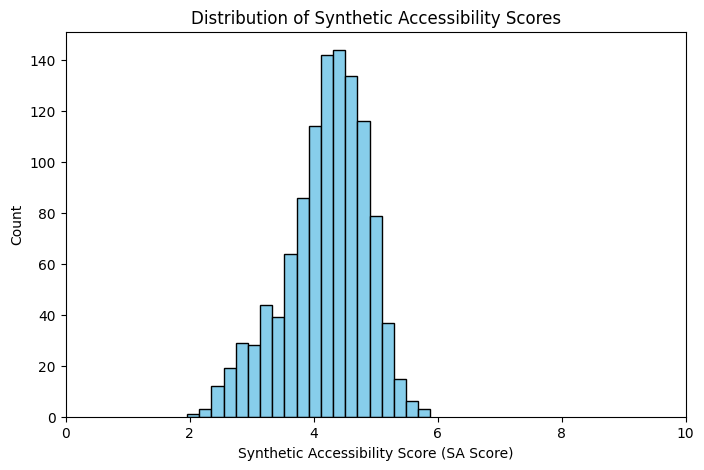

SMILES: NS(=O)(=O)c1ccc(F)cc1-c1ccc(CCO)cc1, SA Score: 1.95933369748934
SMILES: COCc1ccc(C(=O)NCc2ccc3ccccc3c2)c(C(N)=O)n1, SA Score: 2.194347160981332
SMILES: CNC(=O)c1cc(-c2cccc(C#N)c2C(=O)NCc2ccccc2)ccn1, SA Score: 2.253192929278047
SMILES: C=C(C)CCc1ccccc1-c1ccnc(C(=O)NCCO)c1, SA Score: 2.274256222677977
SMILES: CC(=O)NCc1ccc(-c2ccccc2C=O)cc1-c1cc(C(N)=O)ccn1, SA Score: 2.3866741464153414
SMILES: CCc1cccc(-c2cc(NCCNC=O)ccc2F)n1, SA Score: 2.425707466586015
SMILES: CNC(=O)c1cc(NC(=O)c2cccc([N+](=O)[O-])c2NC(C)=O)ncn1, SA Score: 2.431949532800605
SMILES: Nc1nccc(-c2nc(N)ncc2-c2ccccc2-c2ccccn2)n1, SA Score: 2.4439590441195307
SMILES: CC(=O)NCc1cccc(-c2ncc(I)c(CO)n2)c1, SA Score: 2.44596414703979
SMILES: CC(=O)c1ncc(-c2ccc(C(=O)Nc3cccnc3)c(CO)c2)cn1, SA Score: 2.4546941464283183


In [13]:
from gflownet.utils.sascore import calculateScore
sas_scores = []
for smile in good_smiles:
    mol = Chem.MolFromSmiles(smile)
    sascore = calculateScore(mol)
    sas_scores.append(sascore)
    
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(sas_scores, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Synthetic Accessibility Score (SA Score)')
plt.xlim(0, 10)
plt.ylabel('Count')
plt.title('Distribution of Synthetic Accessibility Scores')
plt.show()

top10_indices = np.argsort(sas_scores)[:10]
top10_smiles = [good_smiles[i] for i in top10_indices]
top10_scores = [sas_scores[i] for i in top10_indices]

for s, score in zip(top10_smiles, top10_scores):
    print(f"SMILES: {s}, SA Score: {score}")

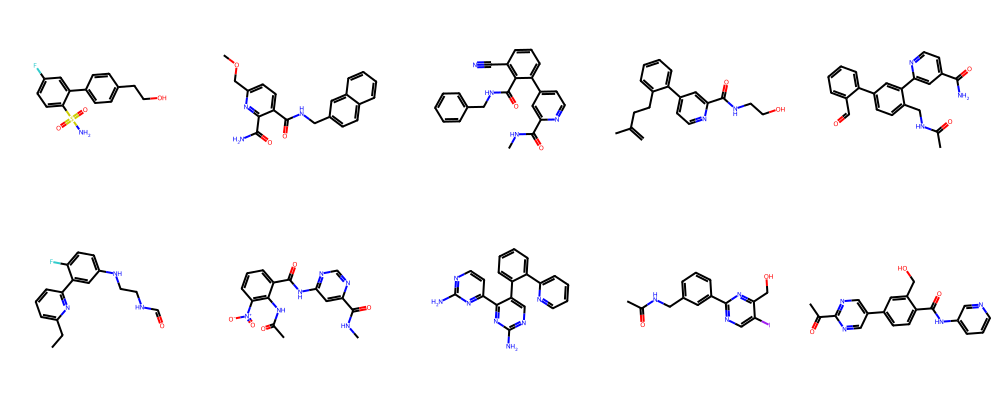

In [14]:
from rdkit.Chem import Draw
from rdkit import Chem

#top_k_df["smiles"]
# Select the first 10 SMILES from top_k_df
mols = [Chem.MolFromSmiles(s) for s in top10_smiles]

# Draw the molecules in a grid
img = Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(200, 200))
img

In [ ]:
df_all = df_all.sort_values(by="reward", ascending=False).reset_index(drop=True)

In [24]:
df_all

,smiles,reward
0,c1ccc(-c2cccc(-c3cc(-c4cc(-c5ccccc5C5CCCCC5)cc...,1.038277
1,C1=CC(c2cccc(C3CCCCC3c3cc(-c4ccccc4)cc4ccccc34...,0.999247
2,CC(C)=CC1CCC(C2CCC(c3cc(-c4ccccc4)cc4ccccc34)C...,0.900149
3,C1=CCC(c2ccc(-c3ccc(C4CCCCC4)c(C4CCC(C5CCCCC5)...,0.876142
4,c1ccc(C2CCC(C3CC(c4ccccc4C4CCCCC4)CCC3c3ccc4cc...,0.873065
...,...,...
495,CNC1CC(O)CC(C2OCCCC2c2ccc(C(C)(C)C)cn2)C1,0.321379
496,CCc1cccc(-c2cc(-c3ccccc3-c3ccc(S(=O)(=O)O)cc3)...,0.319987
497,CC(=O)NC1CCCCC1c1cc(-c2cccnc2)cc(-c2cncc(P(=O)...,0.319370
498,CC(=O)NCC1CCCC(c2ccc(-c3ccc(S(=O)(=O)O)nc3)nc2...,0.287421


In [25]:
# Generate MACCS fingerprints for the SMILES
smiles_1000 = df_all["smiles"][:500]
fingerprints = [generate_maccs_fingerprint(smile) for smile in smiles_1000]

# Calculate pairwise Tanimoto similarities
n = len(fingerprints)
similarity_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(i + 1, n):
        similarity = DataStructs.TanimotoSimilarity(fingerprints[i], fingerprints[j])
        similarity_matrix[i, j] = similarity
        similarity_matrix[j, i] = similarity

# Extract upper triangular values (excluding diagonal) and calculate the average
upper_triangular = similarity_matrix[np.triu_indices(n, k=1)]
average_similarity = np.mean(upper_triangular)

average_similarity

0.39753851751622804

In [96]:
# Calculate the average similarity for each molecule
average_similarities = np.mean(similarity_matrix, axis=1)

# Find the index of the molecule with the lowest average similarity
most_dissimilar_index = np.argmin(average_similarities)

# Retrieve the most dissimilar molecule
most_dissimilar_molecule = smiles[most_dissimilar_index]

most_dissimilar_molecule

'O=P(O)(O)C1OC(c2ccccc2)C(c2ncncc2-c2ccccc2)C1c1ccc2ccccc2c1'

In [85]:
len(bm[0]), len(bm[1])

(1000, 1000)

In [87]:
np.mean(bm[1])

0.6176261

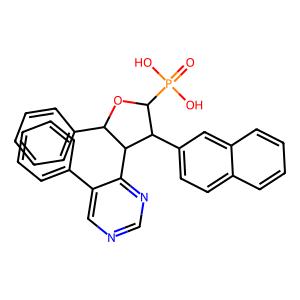

In [97]:
from rdkit.Chem import Draw
from rdkit import Chem
# Select the first 10 molecules from sorted_results
# Convert the most dissimilar molecule's SMILES to an RDKit molecule
most_dissimilar_rdkit_molecule = Chem.MolFromSmiles(most_dissimilar_molecule)

# Plot the most dissimilar molecule
img = Draw.MolToImage(most_dissimilar_rdkit_molecule, size=(300, 300))
img

In [95]:
len(df_all["smiles"])
len(set(list(df_all["smiles"])))    

9999

In [26]:
bm, br = top_k_diverse(df_all)

In [34]:
br

[1.0382774,
 0.7527605,
 0.74636126,
 0.7423072,
 0.74142975,
 0.6721132,
 0.672055,
 0.6605263,
 0.6598427,
 0.6571004,
 0.65594256,
 0.63407016,
 0.6333124,
 0.6309235,
 0.6301847,
 0.6299644,
 0.62205565,
 0.6171947,
 0.6108669,
 0.61068106,
 0.5889769,
 0.5881083,
 0.58775103,
 0.5874138,
 0.58728194,
 0.5865821,
 0.5862756,
 0.5811677,
 0.5801755,
 0.57805824,
 0.5706104,
 0.5702987,
 0.5645994,
 0.56350315,
 0.56337166,
 0.5620318,
 0.55743086,
 0.547246,
 0.5463087,
 0.5451971,
 0.54451627,
 0.54356915,
 0.54347485,
 0.52993727,
 0.52886975,
 0.5239614,
 0.5235072,
 0.52094567,
 0.5164809,
 0.515901,
 0.5055685,
 0.5018987,
 0.48618233,
 0.4859814,
 0.48260474,
 0.4785394,
 0.47257578,
 0.47147584,
 0.47046196,
 0.46094686,
 0.42819566,
 0.42727578,
 0.41398454,
 0.41280854,
 0.37096518,
 0.36879092,
 0.3199873]

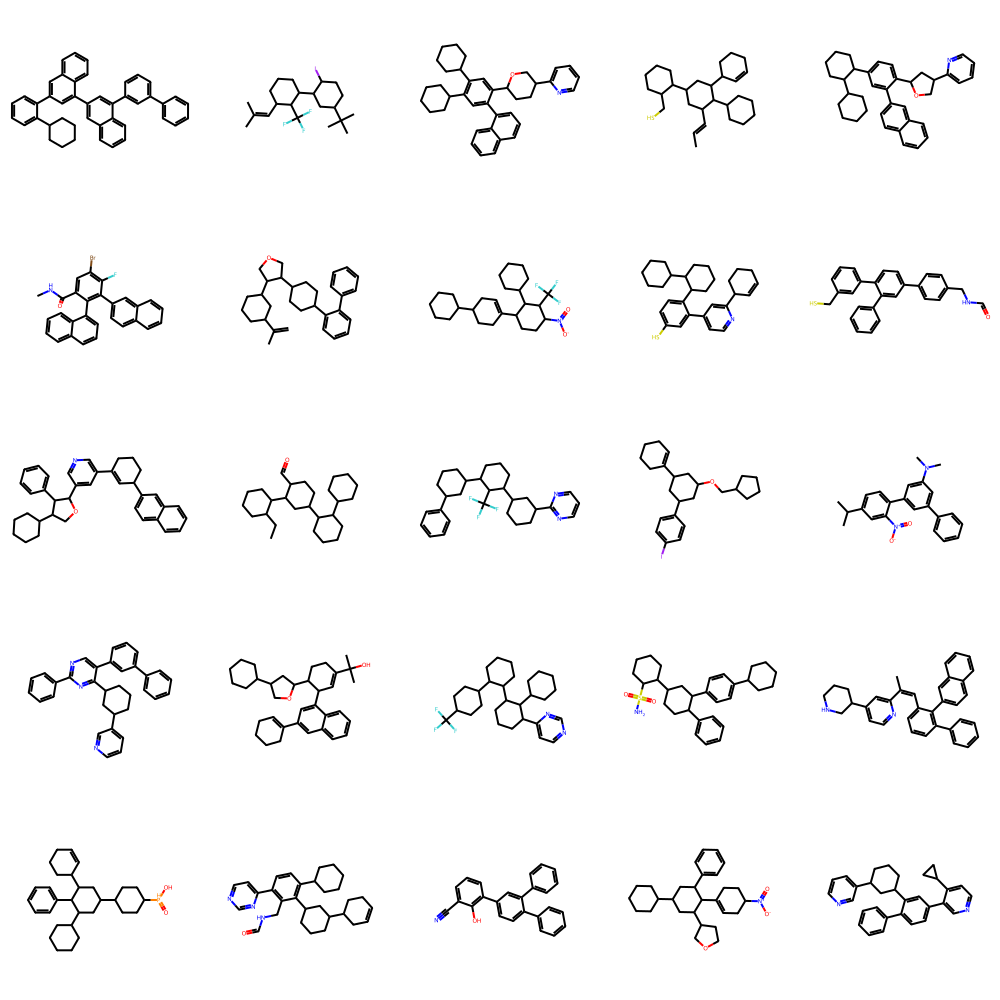

In [33]:
molecules = [Chem.MolFromSmiles(smiles) for smiles in bm[:25]]

# Display the molecules
from rdkit.Chem import Draw
img = Draw.MolsToGridImage(molecules, molsPerRow=5, subImgSize=(200, 200))
img

In [40]:
from rdkit.Chem import QED
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from gflownet.utils.sascore import calculateScore

# If you have the sascorer module, use it; otherwise, use QED as a proxy for synthetic accessibility.
try:
    def compute_sa(smile):
        mol = Chem.MolFromSmiles(smile)
        return calculateScore(mol)
except ImportError:
    def compute_sa(smile):
        mol = Chem.MolFromSmiles(smile)
        # QED is not SA, but can be used as a proxy if sascorer is not available
        return QED.qed(mol)

sa_scores = [compute_sa(smile) for smile in bm[:100]]
sa_scores

[11:58:13] DEPRECATION WARNING: please use MorganGenerator
[11:58:13] DEPRECATION WARNING: please use MorganGenerator
[11:58:13] DEPRECATION WARNING: please use MorganGenerator
[11:58:13] DEPRECATION WARNING: please use MorganGenerator
[11:58:13] DEPRECATION WARNING: please use MorganGenerator
[11:58:13] DEPRECATION WARNING: please use MorganGenerator
[11:58:13] DEPRECATION WARNING: please use MorganGenerator
[11:58:13] DEPRECATION WARNING: please use MorganGenerator
[11:58:13] DEPRECATION WARNING: please use MorganGenerator
[11:58:13] DEPRECATION WARNING: please use MorganGenerator
[11:58:13] DEPRECATION WARNING: please use MorganGenerator
[11:58:13] DEPRECATION WARNING: please use MorganGenerator
[11:58:13] DEPRECATION WARNING: please use MorganGenerator
[11:58:13] DEPRECATION WARNING: please use MorganGenerator
[11:58:13] DEPRECATION WARNING: please use MorganGenerator
[11:58:13] DEPRECATION WARNING: please use MorganGenerator
[11:58:13] DEPRECATION WARNING: please use MorganGenerat

[2.3790976906815278,
 4.71299747339918,
 3.544470042615906,
 4.746303365048532,
 3.8988956755002055,
 2.372046357780551,
 3.7369984423440084,
 4.402364700637094,
 3.9525949624979715,
 2.273686969801128,
 3.9984294033108574,
 4.21025034091042,
 4.245041354132141,
 3.7026859809527277,
 2.1999610387610975,
 3.0861865390751415,
 4.357233617290081,
 4.174706599947223,
 3.8177709356115592,
 3.143863931622972,
 4.64736251872476,
 4.050986929615885,
 1.9925935373005341,
 4.450037588307659,
 3.224473614727387,
 4.4708110104855106,
 4.610513254206289,
 4.584317250738264,
 2.110901195241194,
 4.380906297713617,
 3.995182828401246,
 3.6414056908243033,
 3.825369487827042,
 3.9999249429495976,
 2.3183081796202405,
 3.5687434979826076,
 3.879307522456557,
 2.7104022342851977,
 4.2116303085144375,
 3.954632589603741,
 3.224419660645011,
 2.536824047139689,
 3.5733304205897207,
 3.6164766750197153,
 3.080873647095606,
 4.24680890868611,
 5.386335703507488,
 4.059025350318747,
 3.7452175627701108,
 3.5

In [59]:
bm[5]

'CNC(=O)c1cc(Br)c(F)c(-c2ccc3ccccc3c2)c1-c1cccc2ccccc12'